# Decision Tree — Classification (Iris)

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


In [49]:
data=load_iris(as_frame=True)
df=data.frame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [50]:
X=data.data
y=data.target

In [51]:
df.shape

(150, 5)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [53]:
data.target.sample(10)

49     0
50     1
123    2
28     0
118    2
135    2
132    2
39     0
53     1
64     1
Name: target, dtype: int64

In [54]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

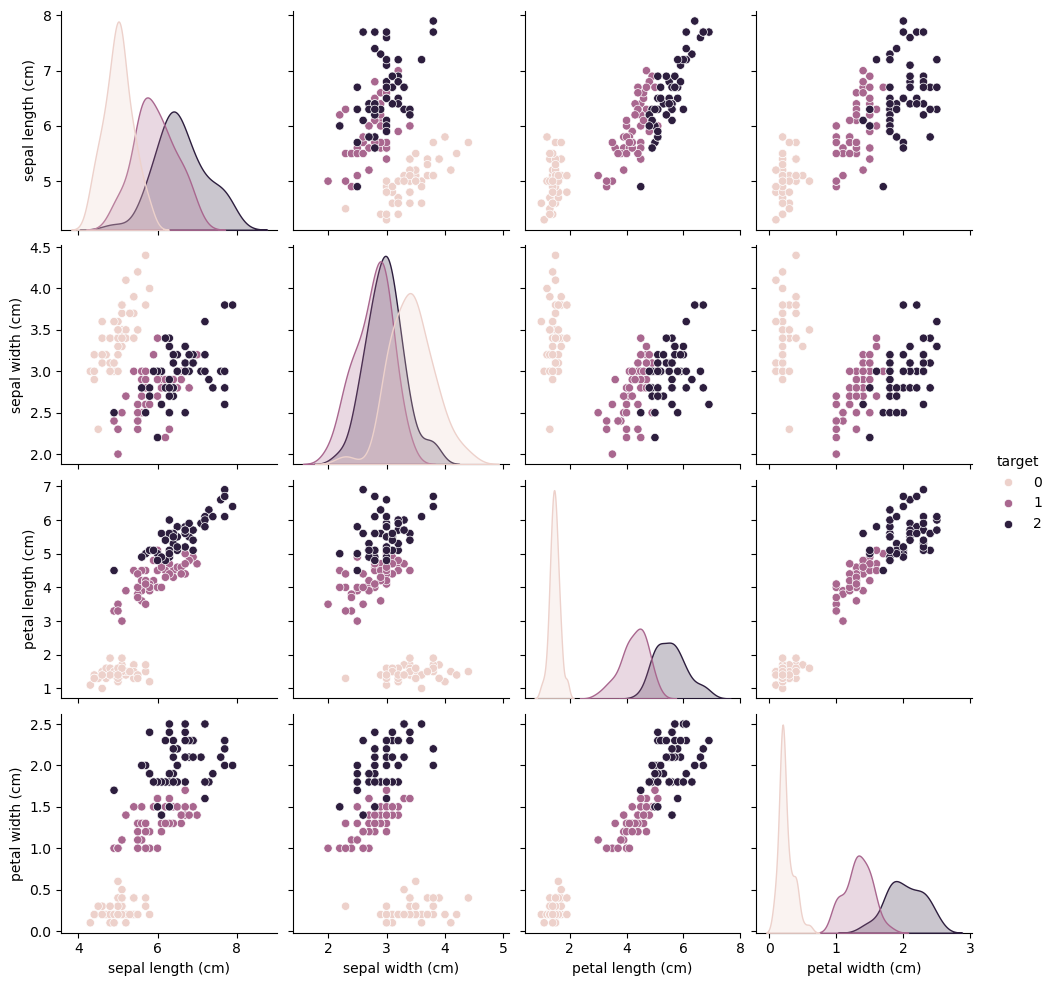

In [55]:
sns.pairplot(df,hue='target')

<Axes: >

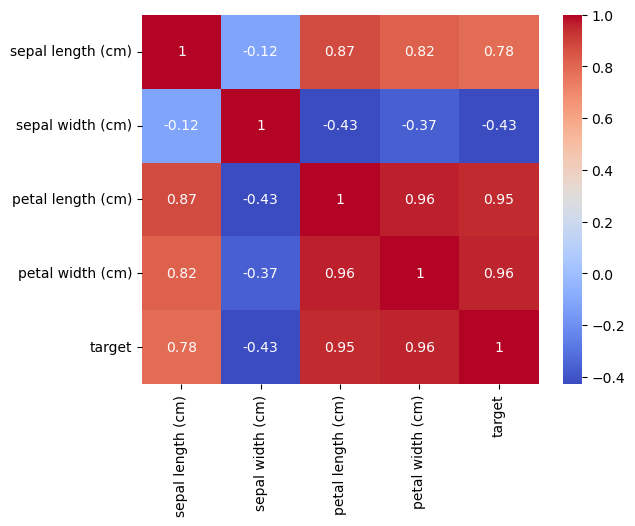

In [56]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [57]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [58]:
baseline=DecisionTreeClassifier(random_state=42)
baseline.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred=baseline.predict(X_test)

In [60]:
pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred}).sample(7)

,Actual,Predicted
16,0,0
12,2,2
27,0,0
13,1,1
22,1,1
21,2,2
8,2,2


In [61]:
accuracy_score(y_test,y_pred)

0.9333333333333333

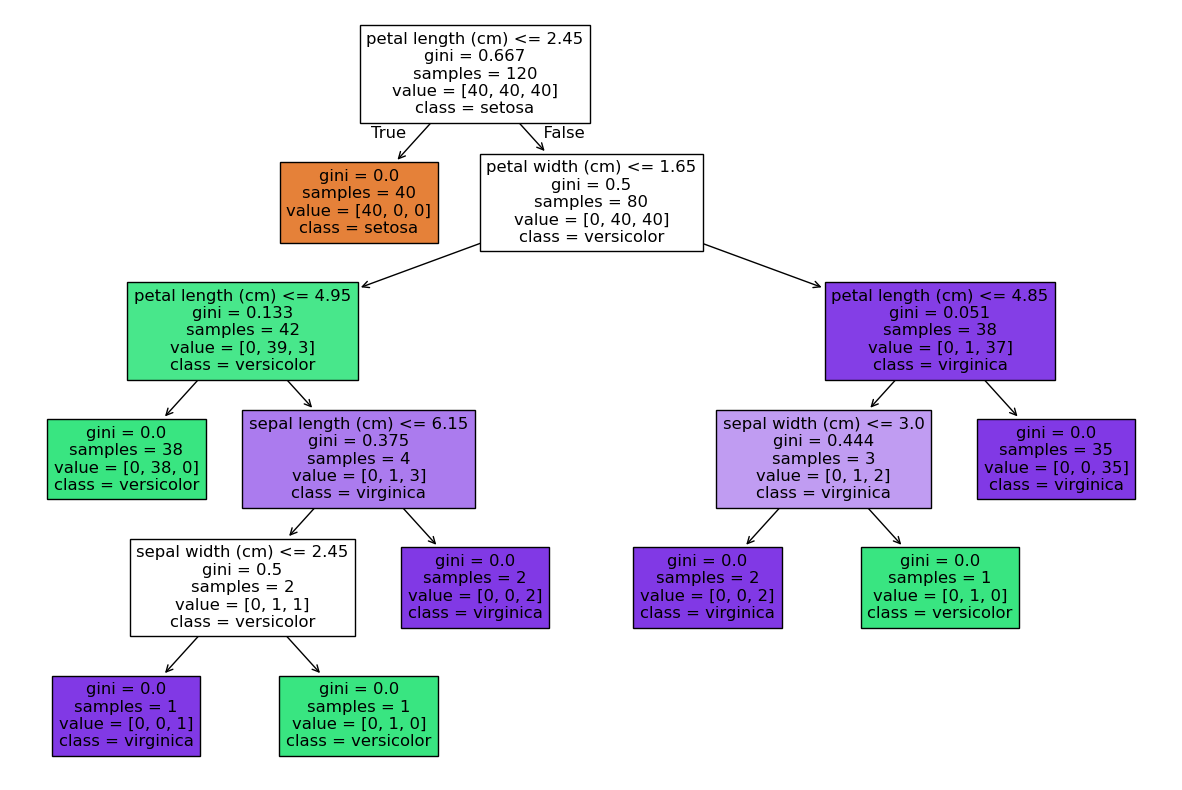

In [62]:
plt.figure(figsize=(15,10))
tree.plot_tree(baseline, filled=True, feature_names=X.columns, class_names=data.target_names)
plt.show()

In [63]:
params={
    'criterion':['gini','entropy'],
    'max_depth':[2, 3, 4, 5, 6],
    'min_samples_split':[2,5,10],
    'max_features':['log2','sqrt']
    }

In [64]:
grid=GridSearchCV(DecisionTreeClassifier(random_state=42),params,cv=5,scoring='accuracy')
grid.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'max_features': ['log2', 'sqrt'], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [65]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 2,
 'max_features': 'log2',
 'min_samples_split': 2}

In [66]:
y_pred_tuned=grid.predict(X_test)


In [67]:
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [68]:
accuracy_score(y_test, y_pred_tuned)

0.9333333333333333

In [69]:
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))
print(roc_auc_score(y_test, grid.predict_proba(X_test), multi_class='ovr'))

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

0.9666666666666667


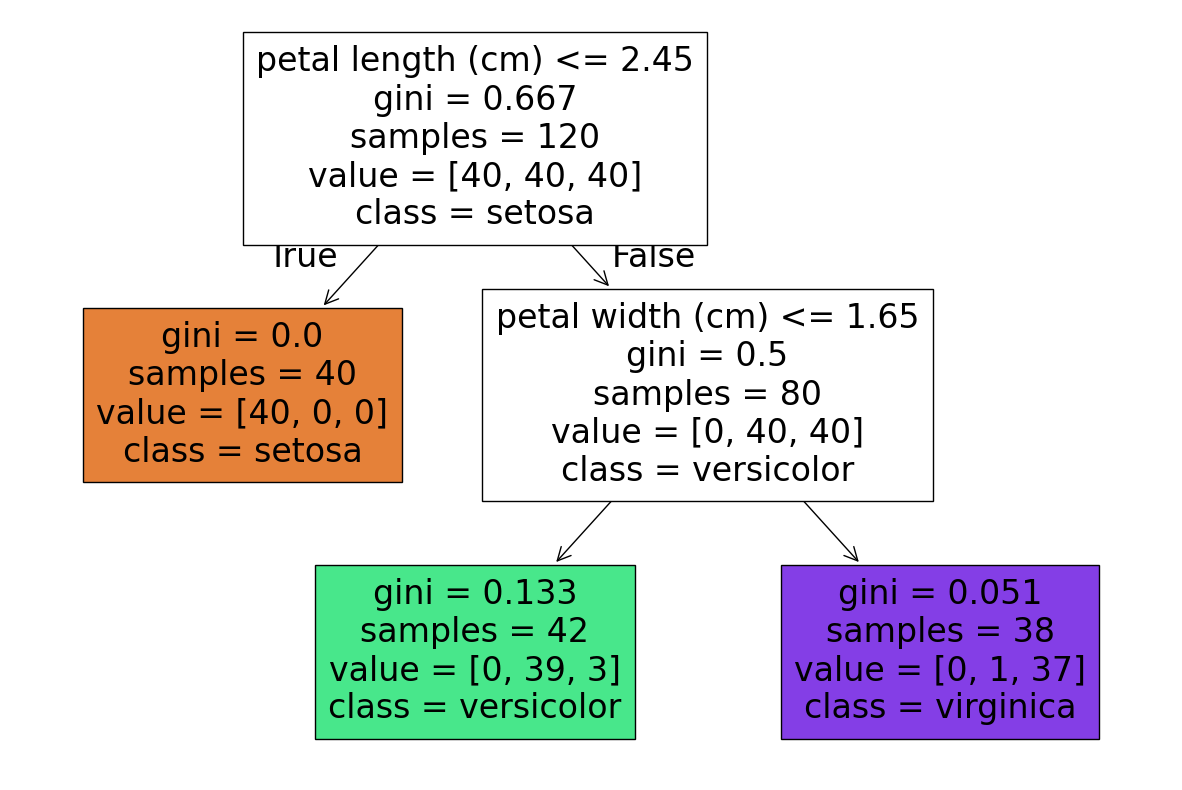

In [70]:
plt.figure(figsize=(15,10))
tree.plot_tree(grid.best_estimator_, filled=True, feature_names=X.columns, class_names=data.target_names)
plt.show()